# 이탈 고객 분석


In [ ]:
# 한글 폰트 설치 및 pycaret 설치 (in Colab)

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')

!pip install -U pip setuptools wheel
!pip install -U scikit-learn imbalanced-learn
!pip install -U "git+https://github.com/pycaret/pycaret.git@master"
!pip install -U jinja2
!pip install catboost
!pip install scikit_posthocs

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (23.3 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and direct

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 17.5 MB/s  0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-h16sddws
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-h16sddws
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
IN

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 47.6 MB/s  0:00:02


In [1]:
# remove warning
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

# Connet Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Data_game')
os.getcwd()

import pandas as pd
df = pd.read_csv('BankChurners.csv')

Mounted at /content/drive


In [2]:
df

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


# 1. 배경: 이탈 고객이 기업에 미치는 영향?

Filed에서 이탈 고객 분석이 중요성

- 신규 고객 유치 비용이 기존 고객 유지 비용보다 5-7배 큼
- 고객 이탈률이 높아지면 당연한 수익성의 저하
- 예측 가능한 이탈 고객을 사전에 파악하면 개인화된 마케팅, 서비스로 유지 시도 가능

분석 포인트
1. 이탈 고객은 어떤 특징을 가지는가?
2. 이탈 예측 모델을 생성할 수 있는가?
3. 이탈 가능성이 높은 고객을 사전에 잡기 위한 전략은?

분석 목표
- 이탈 고객의 특성 정의
- 이탈 가능성 예측 모델 구축
- Action Item 도출

# 2. 분석 기획: 이탈 고객 정의 및 이탈 현황 분석

이탈 고객(Churn)이란?

고객이 일정 기간 동안 서비스를 더 이상 이용하지 않거나 해지한 상태

이탈 여부는 비즈니스 모형에 따라 다양한 방식으로 정의 됨.

- 예
  - 게임: 휴먼 유저(장기간 미접속)
  - 금융: 계좌 해지, 장기 미사용
  - 통신: 해지, 번호 이동
  - 구독: 정기 결제 중단

- 분석 목표


| 단계 | 목적 |
|------|------|
| 1| 이탈 고객 비율 및 특성 파악 |
| 2 | 이탈 예측을 위한 데이터 준비 |
| 3 | 이진 분류 모델을 통한 예측 |
| 4 | 예측된 결과 기반의 전략 도출 |

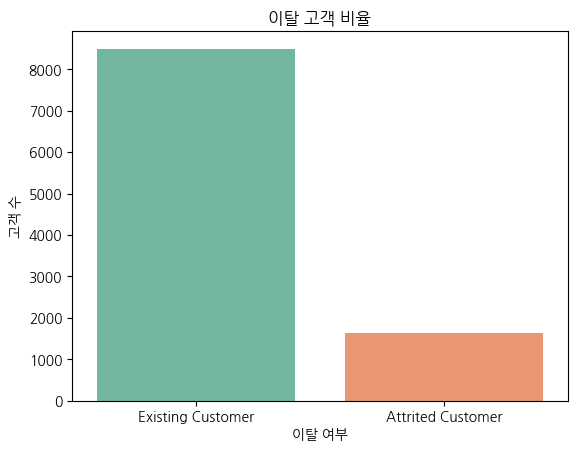

In [ ]:
# 관련 칼럼 확인
## Attrited Flag에 Attrited Customer는 이탈 고객, Existing Customer는 잔존 고객

import pandas as pd

df['Attrition_Flag'].value_counts(normalize=True).map('{:.2%}'.format)

## 시각화

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data = df, x = 'Attrition_Flag', palette='Set2')
plt.title('이탈 고객 비율')
plt.xlabel('이탈 여부')
plt.ylabel('고객 수')
plt.show()

- 이탈 변수 기준 전체 고객의 약 16%가 이탈한 것으로 나타남
- 이탈 고객의 특성과 패턴 분석 후 예측 모델 구성할 기반 마련

# 3. EDA 및 인사이트 도출

목적
- 이탈 고객, 잔존 고객 간 특성 차이 파악
- 예측 모델 설계에 유의미한 변수 선별 후 타겟 마케팅 전략 도출 기반 마련

주요 가설 및 검증
1. 이탈 고객의 소득 수준은 어떤가?
2. 총 거래 횟수나 잔액이 이탈에 영향을 줄까?
3. 이탈 고객은 특정 카드 유형이나 고객 등급에 몰려있는가?

데이터 전처리
- 불필요 칼럼 제거
- 타켓 변수 이진화(0 or 1)

In [ ]:
# 칼럼 확인
df.columns.tolist()

['CLIENTNUM',
 'Attrition_Flag',
 'Customer_Age',
 'Gender',
 'Dependent_count',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category',
 'Months_on_book',
 'Total_Relationship_Count',
 'Months_Inactive_12_mon',
 'Contacts_Count_12_mon',
 'Credit_Limit',
 'Total_Revolving_Bal',
 'Avg_Open_To_Buy',
 'Total_Amt_Chng_Q4_Q1',
 'Total_Trans_Amt',
 'Total_Trans_Ct',
 'Total_Ct_Chng_Q4_Q1',
 'Avg_Utilization_Ratio']

In [ ]:
# 1. 불필요 칼럼인 고유 번호 제거
df = df.drop(columns = ['CLIENTNUM'])

# 2. 타겟 변수 이진화
df['Churn'] = df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

In [ ]:
# 잔존, 이탈 별 기술 통계

numeric_cols = df.select_dtypes(include=['int64', 'float64', 'number']).columns.tolist()
df[numeric_cols].groupby(df['Churn']).mean().T

Churn,0,1
Customer_Age,46.262118,46.659496
Dependent_count,2.335412,2.402581
Months_on_book,35.880588,36.178242
Total_Relationship_Count,3.914588,3.279656
Months_Inactive_12_mon,2.273765,2.693301
Contacts_Count_12_mon,2.356353,2.972342
Credit_Limit,8726.877518,8136.039459
Total_Revolving_Bal,1256.604118,672.822987
Avg_Open_To_Buy,7470.273400,7463.216472
Total_Amt_Chng_Q4_Q1,0.772510,0.694277


변수 정리

|변수명|내용|
|---|---|
|Churn|고객 이탈 여부|
|Gender|성별|
|Customer_Age|연령|
|Education_Level|학력|
|Marital_Status|혼인 여부|
|Dependent_count|	부양가족 수|
|Income_Category|수입 범주|
|Card_Categort|카드 범주|
|Months_on_book|	카드 사용 개월 수|
|Total_Relationship_Count|	보유 금융상품 수|
|Months_Inactive_12_mon|	최근 12개월 비활성 월 수|
|Contacts_Count_12_mon|	고객센터 접촉 횟수|
|Credit_Limit|	카드 한도|
|Total_Revolving_Bal|	리볼빙 잔액|
|Avg_Open_To_Buy|	평균 사용 가능 한도|
|Total_Amt_Chng_Q4_Q1|	사용금액 변화율 (Q4/Q1)|
|Total_Trans_Amt|	총 사용 금액|
|Total_Trans_Ct|	총 거래 횟수|
|Total_Ct_Chng_Q4_Q1|	거래 횟수 변화율|
|Avg_Utilization_Ratio|	평균 한도 사용률|

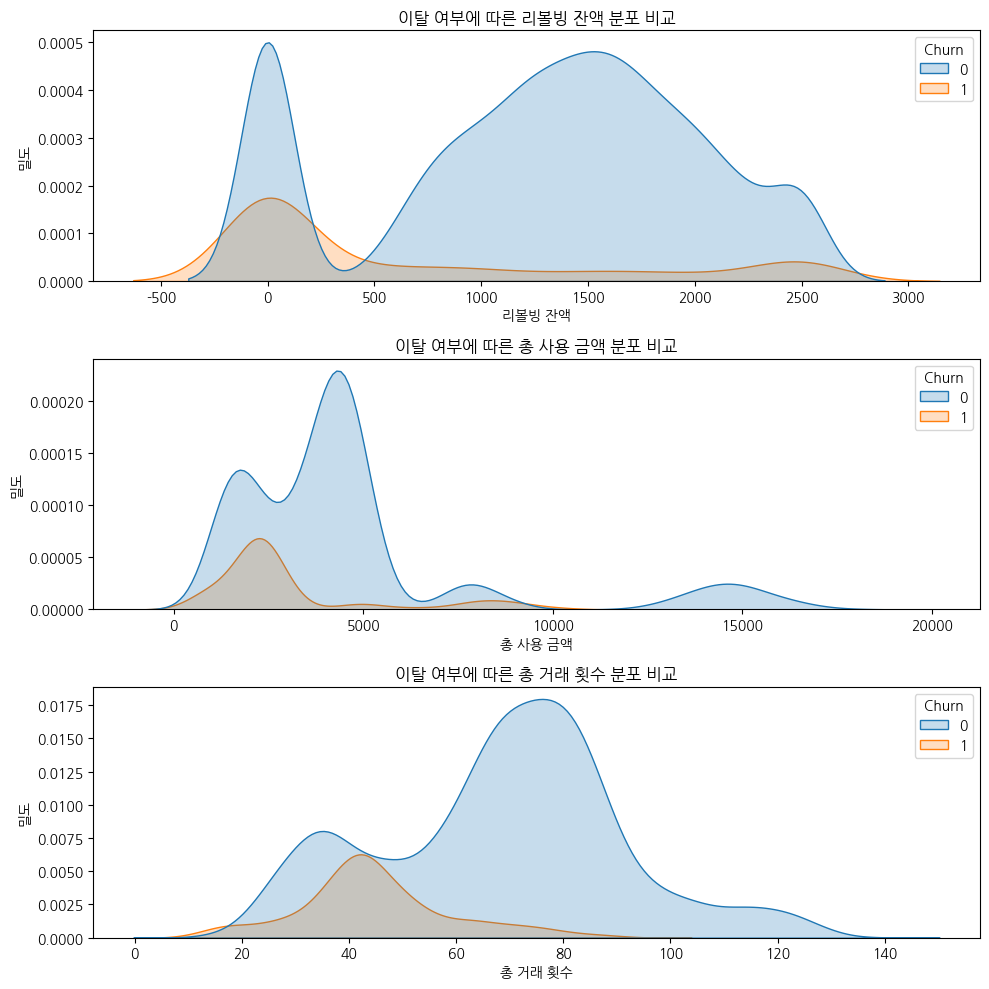

In [ ]:
# 기술 통계에서 차이가 커 보이는 주요 변수들의 차이 시각화

fig, axes = plt.subplots(3, 1, figsize = (10, 10))

sns.kdeplot(data = df, x = 'Total_Revolving_Bal', hue = 'Churn', fill = True, ax = axes[0])
axes[0].set_title('이탈 여부에 따른 리볼빙 잔액 분포 비교')
axes[0].set_xlabel('리볼빙 잔액')
axes[0].set_ylabel('밀도')

sns.kdeplot(data = df, x = 'Total_Trans_Amt', hue = 'Churn', fill = True, ax = axes[1])
axes[1].set_title('이탈 여부에 따른 총 사용 금액 분포 비교')
axes[1].set_xlabel('총 사용 금액')
axes[1].set_ylabel('밀도')

sns.kdeplot(data = df, x = 'Total_Trans_Ct', hue = 'Churn', fill = True, ax = axes[2])
axes[2].set_title('이탈 여부에 따른 총 거래 횟수 분포 비교')
axes[2].set_xlabel('총 거래 횟수')
axes[2].set_ylabel('밀도')

plt.tight_layout()
plt.show()

1. 리볼빙 잔액 분포

- 잔존 고객은 고잔액 구간(1,000_2,500)과 저잔액 구간(-400_400)구간에 봉우리
- 이탈 고객은 0에 강하게 집중하며 고잔액 구간에서는 거의 밀도가 없음

- 이탈 고객은 이미 리볼빙을 거의 쓰지 않는 상태
- 카드 사용 자체를 중단한 뒤 이탈

- 리볼빙 잔액 감소가 이탈 전 단계의 신호일 수도
- 고잔액 고객은 오히려 이탈 가능성이 낮은 핵심 수익군

- 사실 카드 자체를 잘 사용하지 않아 이탈 조직이 0 근처에 집중하는 것으로 판단하는 것이 좋음.

2. 총 사용 금액 분포

- 잔존 조객은 중간 사용 구간인 3,000_6,000 + 고사용 아웃라이어인 10,000이상 존재
- 이탈 고객은 저사용 구간인 1,000_3,000에 집중, 고사용 구간 없음

- 이탈 고객은 갑자기 안쓰는 고객이라고 못볼수도 잇음
- 이미 사용 강도가 낮은 상태가 오래 지속

- 고사용 고객 유지 전략과 저 사용 고객 유지 전략을 동시에 가져가면 안됨

3. 총 거래 횟수 분포

- 잔존 고객은 60_90회 구간에 가장 큰 봉우리(생활비, 고정 사용 패턴 일수)
- 이탈 고객은 30_50회 구간에 집중(고빈도 구간 거의 없음)

- 이탈은 금액 감소보다도 빈도 감소의 패턴이 뚜렷할 듯
- 카드가 생활 카드 -> 가끔 쓰는 카드 -> 안쓰는 카드로 변화

- 빈도 감소 -> 다음 분기 이탈 구조 강함

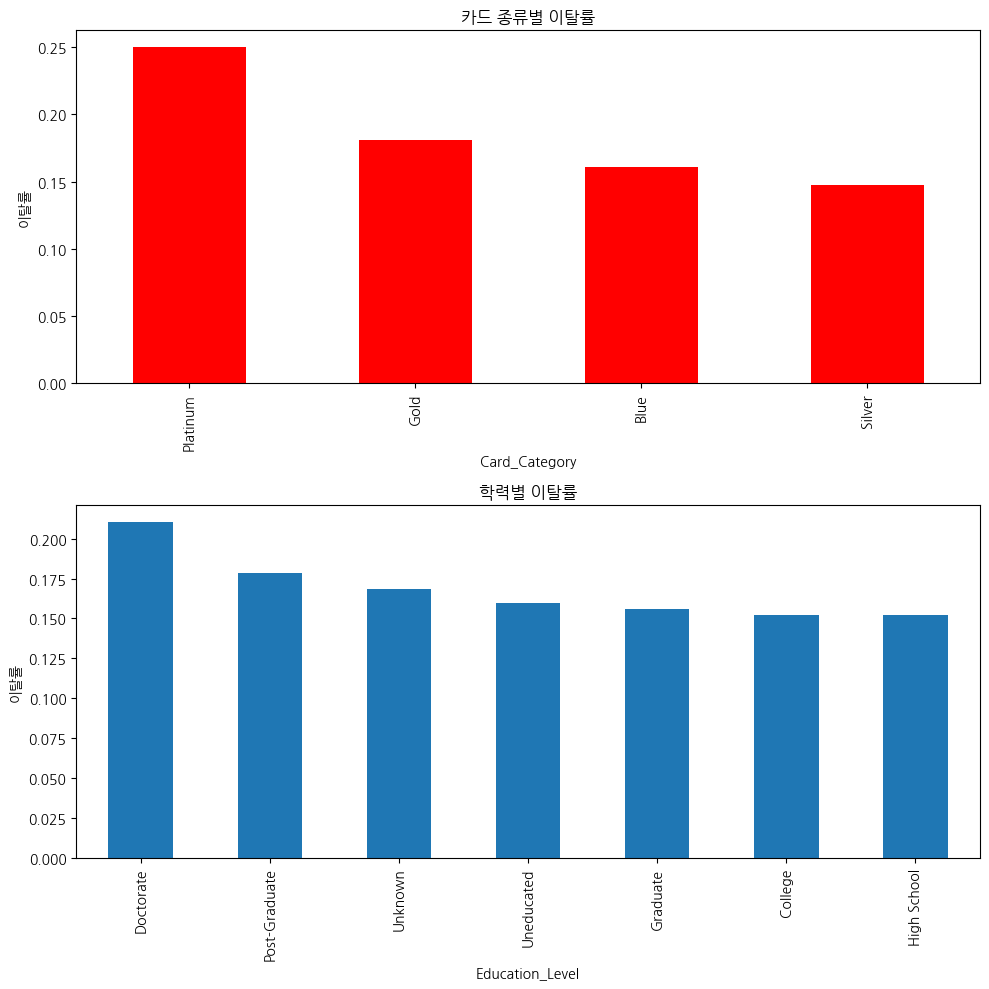

In [ ]:
# 카드 카테고리, 학력 별 이탈 비율

churn_rate_by_cat = df.groupby('Card_Category')['Churn'].mean().sort_values(ascending=False)
churn_rate_by_edu = df.groupby('Education_Level')['Churn'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize = (10, 10))

churn_rate_by_cat.plot(kind = 'bar', color = 'red', title = '카드 종류별 이탈률', ax = axes[0])
axes[0].set_ylabel('이탈률')

churn_rate_by_edu.plot(kind = 'bar', title = '학력별 이탈률', ax = axes[1])
axes[1].set_ylabel('이탈률')

plt.tight_layout()
plt.show()

1. 카드별

- 카드 등급이 높을 수록 이탈률이 높아짐
- 프리미엄 고객은 충성도가 높다는 일반적인 직관과는 반대되는 결과가 나오고 있음

- 프리미엄 고객은 선택권이 많은 고객으로 다른 카드, 다른 금융사 대안이 많음. 혜택이 민감하고 기대 대비 불만시 즉시 이탈할 가능성 존재
- 실버 고객은 생활 밀착형으로 혜택보다는 인숙함이 중요할 수 있음

2. 학력별

- 고학력일 수록 정보 탐색 능력이 높고, 조건 및 혜택 변화에 민감할 수 있음

# 3. 이탈 고객 예측 모델링

목적

- 고객의 이탈 여부 분류 모델 구축
- 모델을 통해 이탈 가능성 높은 고객군 사전 식별
- 추후 전략적 마케팅 및 retention 활동에 적용할 수 있도록 기반 마련

모델

- pycaret을 통해 상위 모델 확인 후 해당 모델 적합

타겟 및 특성 정의

- 타켓: Churn (1=이탈, 0=잔존)
- feature: 범주형 인코딩 및 수치형 스케일링 후 사용
> pycaret을 이용하여 자동화

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
from pycaret.classification import *

# 10-fold × 5 repeats (총 25 분할)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=24)

#df.drop(columns = ['Attrition_Flag'], inplace = True)

# 동일 전처리/시드
clf = setup(
    data=df,                    # 전처리된 데이터프레임
    target='Churn',           # 종속변수 (0/1)
    session_id=24,              # 재현성
    fold_strategy=cv,           # 동일 분할기 공유
    fold=10,                     # 내부 표기(무시되지 않도록 유지)
    verbose=False,
    normalize_method = "zscore"
)

candidates = [
'lr', 'nb', 'knn', 'catboost',
    'dt', 'rf', 'gbc', 'xgboost',
    'lightgbm', 'svm'
]

# 각 모델 동일조건 튜닝(AUC 기준)
tuned_models = []
for code in candidates:
    base = create_model(code, cross_validation=True)  # 1차 성능 확인
    tuned = tune_model(
        base, optimize='AUC',
        n_iter=10,
        choose_better=True,     # 개선 시 교체
        fold=cv
    )
    tuned_models.append(tuned)

# 재평가(per-fold 원점수 추출)
all_results = []
for m in tuned_models:
    _ = create_model(m, cross_validation=True, fold=cv)
    res = pull().copy()                 # 분할별 메트릭 테이블
    res['model'] = m.__class__.__name__
    all_results.append(res)

res_df = pd.concat(all_results, ignore_index=True)

# 모델별 평균/SD/SE 계산 (SE = SD/sqrt(50))
metrics = ['Accuracy','AUC','Recall','Prec.','F1']
summary = (res_df
           .groupby('model')[metrics]
           .agg(['mean','std'])
          )
for met in metrics:
    summary[(met, 'SE')] = summary[(met, 'std')] / np.sqrt(50)

# 보기 좋게 열 정리
summary = summary.swaplevel(0,1,axis=1).sort_index(axis=1)
print(summary)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9083,0.9014,0.5789,0.7952,0.6701,0.6183,0.6288
1,0.8886,0.9112,0.5088,0.7160,0.5949,0.5324,0.5429
2,0.8942,0.9182,0.5965,0.7010,0.6445,0.5829,0.5855
3,0.8928,0.9177,0.4561,0.7879,0.5778,0.5213,0.5469
4,0.8956,0.9185,0.5175,0.7564,0.6146,0.5567,0.5701
5,0.9013,0.9186,0.5351,0.7821,0.6354,0.5806,0.5946
6,0.8858,0.9054,0.5000,0.7037,0.5846,0.5206,0.5308
7,0.9210,0.9472,0.6579,0.8152,0.7282,0.6826,0.6879
8,0.9096,0.9163,0.6106,0.7753,0.6832,0.6313,0.6374


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8970,0.8980,0.5439,0.7470,0.6294,0.5714,0.5811
1,0.8900,0.9147,0.5175,0.7195,0.6020,0.5402,0.5501
2,0.8886,0.9185,0.6053,0.6699,0.6359,0.5704,0.5714
3,0.9013,0.9155,0.4825,0.8333,0.6111,0.5591,0.5866
4,0.8970,0.9200,0.5263,0.7595,0.6218,0.5644,0.5772
5,0.9027,0.9181,0.5439,0.7848,0.6425,0.5883,0.6016
6,0.8900,0.9059,0.5088,0.7250,0.5979,0.5365,0.5478
7,0.9210,0.9472,0.6579,0.8152,0.7282,0.6826,0.6879
8,0.9110,0.9161,0.5929,0.7976,0.6802,0.6298,0.6392


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 50 folds for each of 10 candidates, totalling 500 fits


...

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9676,0.9908,0.8421,0.9505,0.8930,0.8740,0.8762
1,0.9760,0.9958,0.9035,0.9450,0.9238,0.9095,0.9099
2,0.9718,0.9951,0.9123,0.9123,0.9123,0.8955,0.8955
3,0.9661,0.9902,0.8158,0.9688,0.8857,0.8660,0.8704
4,0.9661,0.9903,0.8860,0.9018,0.8938,0.8737,0.8737
5,0.9760,0.9959,0.9211,0.9292,0.9251,0.9108,0.9108
6,0.9746,0.9932,0.9123,0.9286,0.9204,0.9053,0.9053
7,0.9803,0.9966,0.9298,0.9464,0.9381,0.9263,0.9264
8,0.9732,0.9947,0.8761,0.9519,0.9124,0.8966,0.8977


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8364,0.8348,0.4211,0.4898,0.4528,0.3573,0.3587
1,0.8519,0.8549,0.3947,0.5556,0.4615,0.3785,0.3860
2,0.8336,0.8592,0.6667,0.4872,0.5630,0.4632,0.4719
3,0.8688,0.8140,0.2719,0.7561,0.4000,0.3442,0.4015
4,0.8646,0.8036,0.3158,0.6667,0.4286,0.3627,0.3954
5,0.7997,0.8414,0.6754,0.4231,0.5203,0.4020,0.4196
6,0.8279,0.8350,0.4561,0.4643,0.4602,0.3578,0.3579
7,0.8265,0.8342,0.5702,0.4676,0.5138,0.4095,0.4125
8,0.8432,0.8591,0.5575,0.5081,0.5316,0.4377,0.4384


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

NameError: name 'np' is not defined

In [ ]:
import numpy as np

for met in metrics:
    summary[(met, 'SE')] = summary[(met, 'std')] / np.sqrt(50)

# 보기 좋게 열 정리
summary = summary.swaplevel(0,1,axis=1).sort_index(axis=1)
print(summary)

                                  SE                                          \
                                 AUC  Accuracy        F1     Prec.    Recall   
model                                                                          
CatBoostClassifier          0.019456  0.018990  0.017762  0.018274  0.017406   
DecisionTreeClassifier      0.017906  0.018295  0.015715  0.016240  0.015571   
GaussianNB                  0.017047  0.017448  0.013231  0.014273  0.013027   
GradientBoostingClassifier  0.019383  0.018874  0.017361  0.018293  0.016659   
KNeighborsClassifier        0.017836  0.017339  0.012360  0.014698  0.011506   
LGBMClassifier              0.019435  0.018966  0.017690  0.018140  0.017418   
LogisticRegression          0.017815  0.017487  0.012928  0.015547  0.011759   
RandomForestClassifier      0.019270  0.018642  0.016536  0.018147  0.015493   
SGDClassifier               0.016329  0.016380  0.011673  0.015891  0.019470   
XGBClassifier               0.019418  0.

- AUC기준 XGB가 가장 높음

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
from pycaret.classification import *


# xgboost 적합

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=24)

#df.drop(columns = ['Attrition_Flag'], inplace = True)

# 동일 전처리/시드
clf = setup(
    data=df,                    # 전처리된 데이터프레임
    target='Churn',           # 종속변수 (0/1)
    session_id=24,              # 재현성
    fold_strategy=cv,           # 동일 분할기 공유
    fold=10,                     # 내부 표기(무시되지 않도록 유지)
    verbose=False,
    normalize_method = "zscore"
)

xg_model = create_model('xgboost')
tuned_xg = tune_model(
    xg_model,
    optimize = 'AUC',
    choose_better = True,
    n_iter = 10
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9647,0.9920,0.8333,0.9406,0.8837,0.8630,0.8652
1,0.9774,0.9954,0.9211,0.9375,0.9292,0.9158,0.9158
2,0.9647,0.9917,0.8947,0.8870,0.8908,0.8698,0.8698
3,0.9647,0.9884,0.8158,0.9588,0.8815,0.8610,0.8648
4,0.9633,0.9883,0.8684,0.9000,0.8839,0.8622,0.8624
5,0.9746,0.9958,0.9123,0.9286,0.9204,0.9053,0.9053
6,0.9732,0.9927,0.9035,0.9279,0.9156,0.8996,0.8997
7,0.9774,0.9963,0.9211,0.9375,0.9292,0.9158,0.9158
8,0.9746,0.9945,0.8850,0.9524,0.9174,0.9024,0.9033


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9633,0.9873,0.8947,0.8793,0.8870,0.8651,0.8651
1,0.9732,0.9938,0.9561,0.8862,0.9198,0.9038,0.9047
2,0.9591,0.9941,0.9561,0.8195,0.8826,0.8580,0.8617
3,0.9704,0.9836,0.8947,0.9189,0.9067,0.8891,0.8892
4,0.9563,0.9896,0.9474,0.8120,0.8745,0.8482,0.8519
5,0.9619,0.9933,0.9561,0.8321,0.8898,0.8669,0.8700
6,0.9605,0.9886,0.9298,0.8413,0.8833,0.8596,0.8612
7,0.9774,0.9968,0.9737,0.8952,0.9328,0.9192,0.9204
8,0.9746,0.9916,0.9381,0.9060,0.9217,0.9066,0.9068


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 50 folds for each of 10 candidates, totalling 500 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [ ]:
final_model = finalize_model(tuned_xg)

In [ ]:
X_train = get_config('X_train')
X_train

,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
336,56,F,1,Graduate,Married,Less than $40K,Blue,38,4,3,3,2578.0,2462,116.0,1.707,1378,29,0.812,0.955
8141,47,M,2,High School,Single,$40K - $60K,Blue,27,2,3,2,1536.0,0,1536.0,0.913,4643,89,0.745,0.000
5716,53,F,4,Graduate,Single,Less than $40K,Blue,46,4,1,2,4117.0,777,3340.0,0.592,5218,88,0.600,0.189
3526,57,F,1,High School,Single,Less than $40K,Blue,45,5,2,4,5330.0,0,5330.0,0.515,3525,79,0.837,0.000
6791,44,F,3,Graduate,Married,Less than $40K,Blue,36,6,5,3,2420.0,1223,1197.0,0.718,4954,82,0.783,0.505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3573,62,F,2,Doctorate,Single,$40K - $60K,Blue,56,5,3,2,6797.0,1428,5369.0,0.747,3962,70,0.795,0.210
7185,46,M,3,Unknown,Married,$80K - $120K,Blue,40,6,1,1,10879.0,860,10019.0,0.974,4629,69,0.725,0.079
9876,46,M,2,High School,Single,$60K - $80K,Blue,34,2,2,1,10325.0,0,10325.0,0.866,16856,122,0.718,0.000
1035,48,M,4,Graduate,Unknown,$80K - $120K,Blue,40,6,2,2,4438.0,2472,1966.0,0.690,1725,60,0.622,0.557


In [ ]:
import pandas as pd
import xgboost as xgb

X_train_raw = get_config('X_train')
X_test_raw  = get_config('X_test')
y_train     = get_config('y_train')
y_test      = get_config('y_test')

Xy_train = xgb.DMatrix(X_train_raw, y_train, enable_categorical=True)
Xy_valid = xgb.DMatrix(X_test_raw, y_test, enable_categorical=True)

params = tuned_xg.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': 'gbtree',
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': 'cpu',
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 24,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': 'auto',
 'validate_parameters': None,
 'verbosity': 0}

In [ ]:
# (중요) PyCaret이 넣어둔 불필요/충돌 파라미터가 있을 수 있어서 가드
safe_params = params.copy()

# tree_method, eval_metric 등은 환경에 따라 자동 설정되기도 해서 그대로 둬도 OK
booster = xgb.train(params, Xy_train)

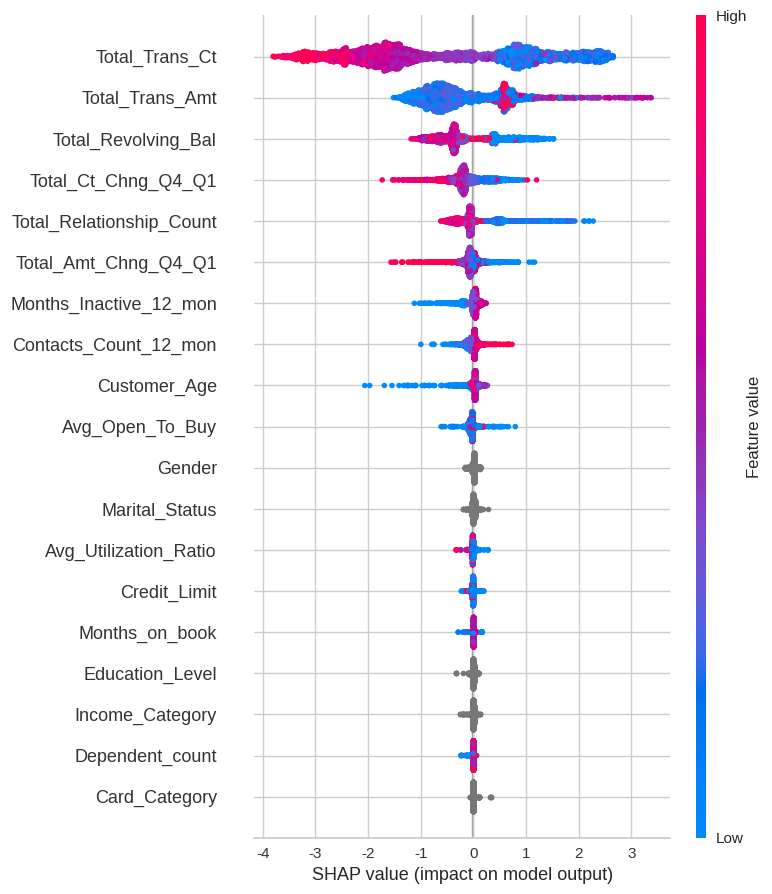

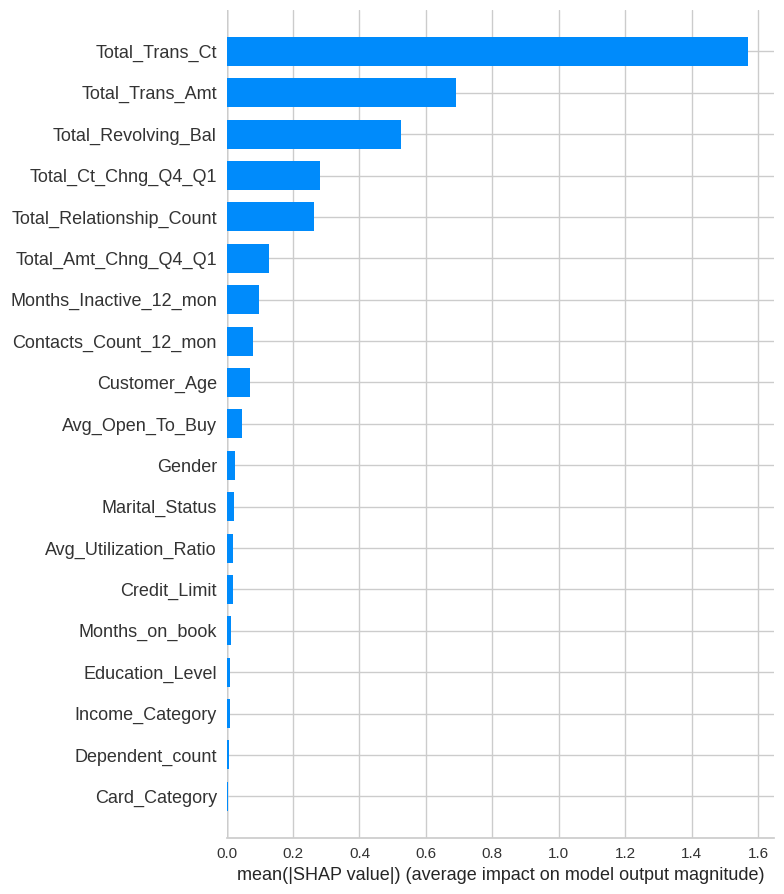

In [ ]:
import shap

# TreeExplainer는 Booster를 직접 받을 수 있음
explainer = shap.TreeExplainer(booster)

# DMatrix로 shap_values 계산(권장)
shap_values = explainer.shap_values(Xy_valid)

# summary_plot은 보통 numpy + feature matrix가 필요함
shap.summary_plot(shap_values, X_test_raw, feature_names=X_test_raw.columns)
shap.summary_plot(shap_values, X_test_raw, plot_type="bar", feature_names=X_test_raw.columns)


앞서 EDA를 통해 확인한 것과 같이 1. 리볼빙 잔액, 2. 총 사용 금액, 3. 총 거래 횟수 이 셋이 가장 중요, 그 중에도 총 거래 횟수가 가장 중요한 것으로 나타남

# 5. 성과 분석 및 전략 도출

목적

- 예측된 이탈 위험 고객군에 대해
- 특징 분석을 통해 관리 전략 수립
- 데이터 기반으로 Action Plan 제안

대상: 이탈 확률이 높은 고객군
- XGB 모델 기준 이탈 확률 >= 0.7 이상인 고객을 고 위험군으로 정의

In [ ]:
# 3) 확률 예측 (binary:logistic이면 확률)
# 훈련 데이터에 대한 예측
train_preds = booster.predict(Xy_train)
# 테스트 데이터에 대한 예측
test_preds = booster.predict(Xy_valid)

# 원본 df의 인덱스를 사용하여 예측값을 Series로 변환
df_churn_prob_train = pd.Series(train_preds, index=X_train_raw.index)
df_churn_prob_test = pd.Series(test_preds, index=X_test_raw.index)

# 전체 df의 인덱스에 맞춰 예측값을 결합하고 정렬
all_churn_probs = pd.concat([df_churn_prob_train, df_churn_prob_test]).sort_index()

# 원본 df에 churn_prob 컬럼 추가
df['churn_prob'] = all_churn_probs

# 4) 고위험 고객 필터
high_risk = df[df['churn_prob'] >= 0.7]

print(f"이탈 고위험 고객 수: {len(high_risk)}명")
high_risk[['Total_Trans_Ct', 'Customer_Age', 'Dependent_count', 'churn_prob']].head()

이탈 고위험 고객 수: 1313명


,Total_Trans_Ct,Customer_Age,Dependent_count,churn_prob
21,16,62,0,0.958874
37,22,42,4,0.904322
39,16,66,0,0.738437
51,19,54,1,0.856745
54,15,56,2,0.959057


In [ ]:
# 분석에서 제외할 컬럼
exclude_cols = ['Churn', 'churn_prob', 'risk_group']

# 연속형 변수: 숫자형
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.difference(exclude_cols)

# 범주형 변수
cat_cols = df.select_dtypes(include=['object', 'category']).columns.difference(exclude_cols)

num_cols, cat_cols


(Index(['Avg_Open_To_Buy', 'Avg_Utilization_Ratio', 'Contacts_Count_12_mon',
        'Credit_Limit', 'Customer_Age', 'Dependent_count',
        'Months_Inactive_12_mon', 'Months_on_book', 'Total_Amt_Chng_Q4_Q1',
        'Total_Ct_Chng_Q4_Q1', 'Total_Relationship_Count',
        'Total_Revolving_Bal', 'Total_Trans_Amt', 'Total_Trans_Ct'],
       dtype='object'),
 Index(['Card_Category', 'Education_Level', 'Gender', 'Income_Category',
        'Marital_Status'],
       dtype='object'))

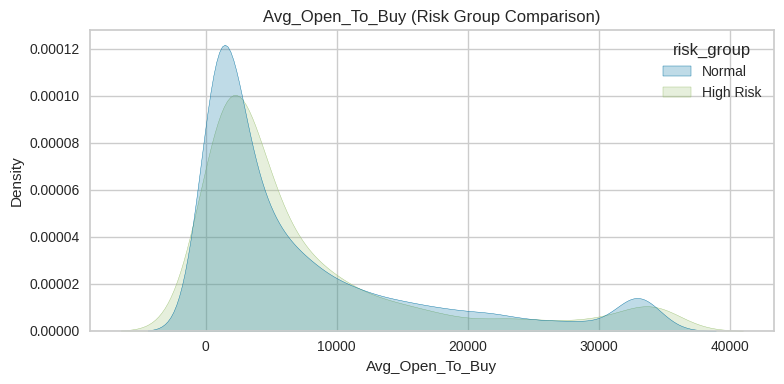

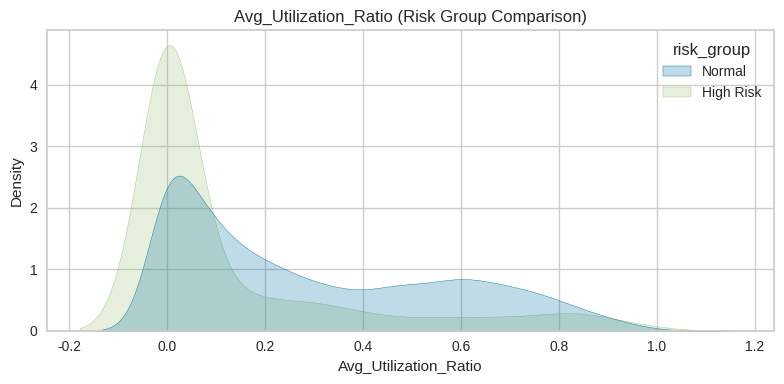

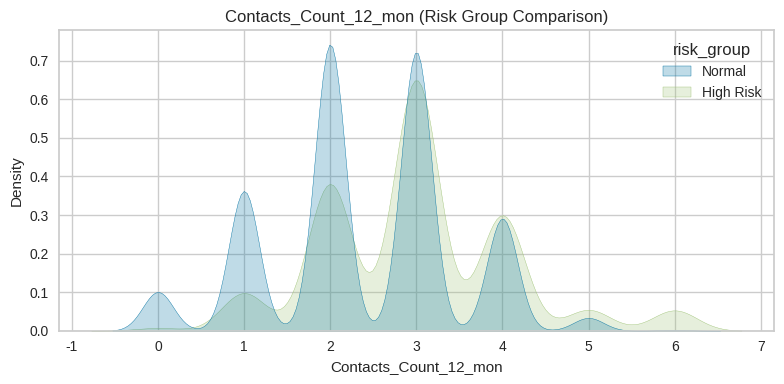

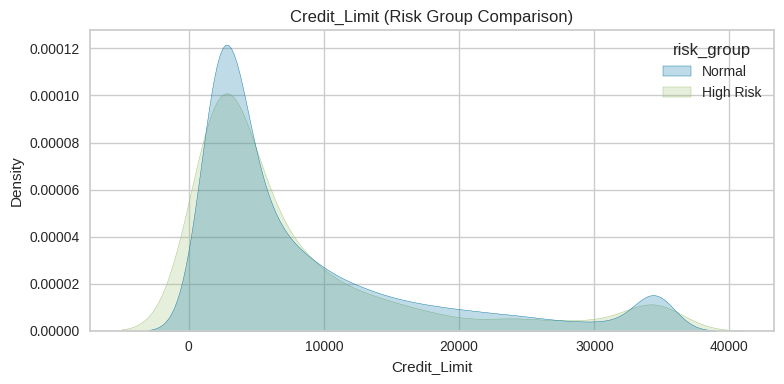

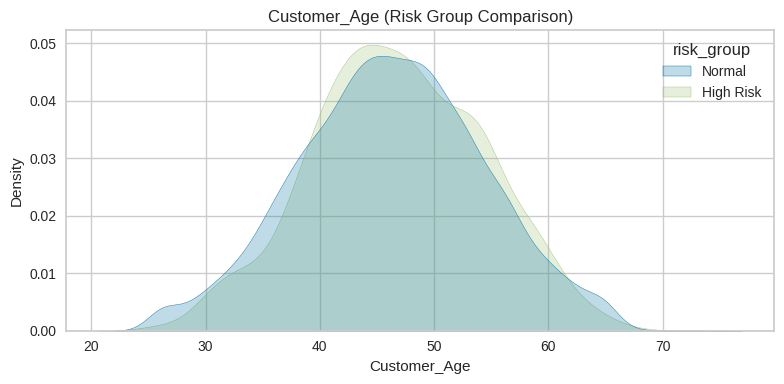

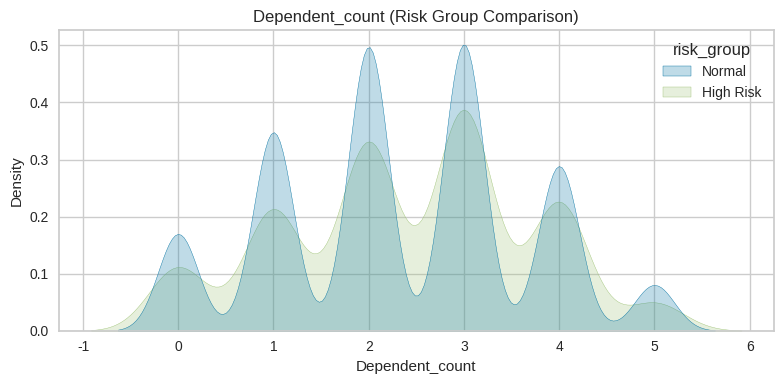

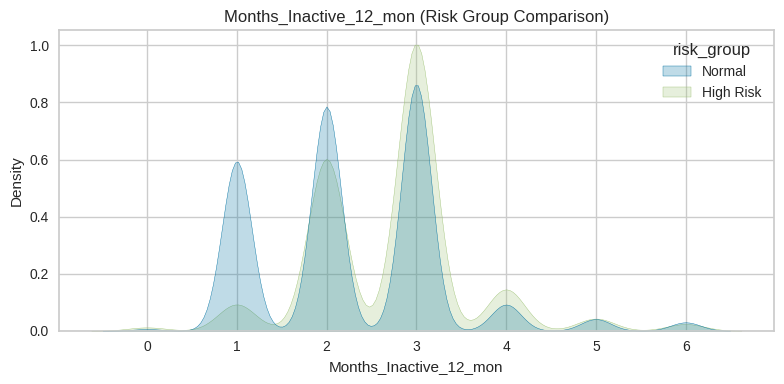

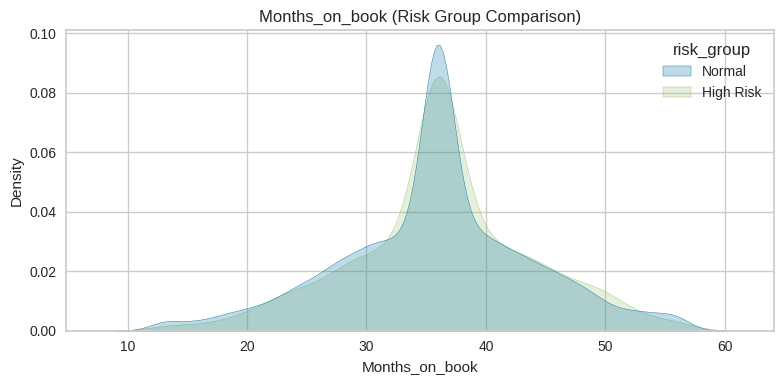

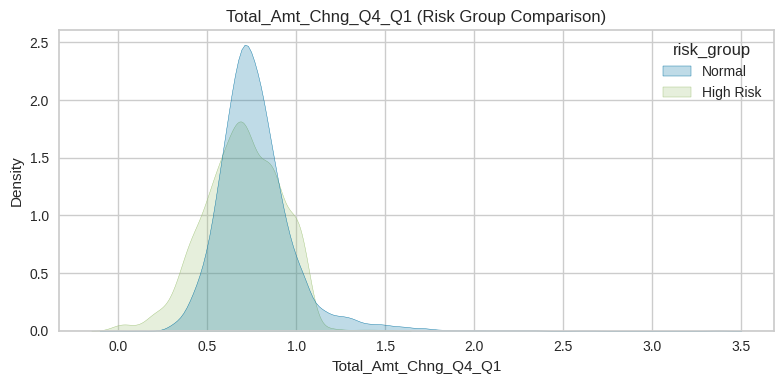

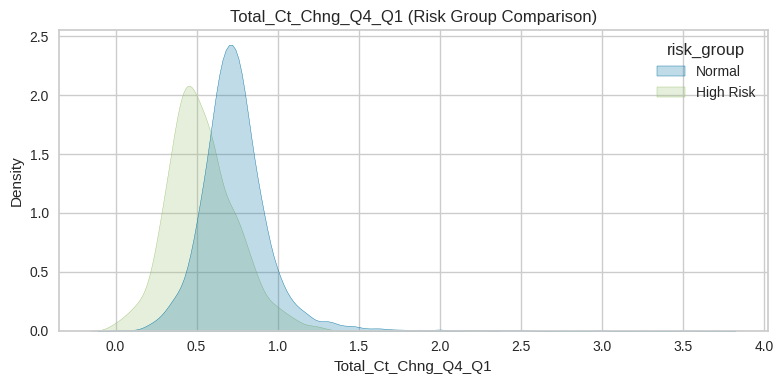

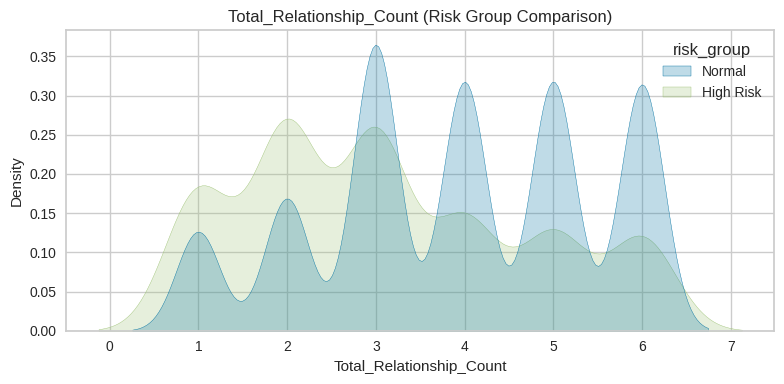

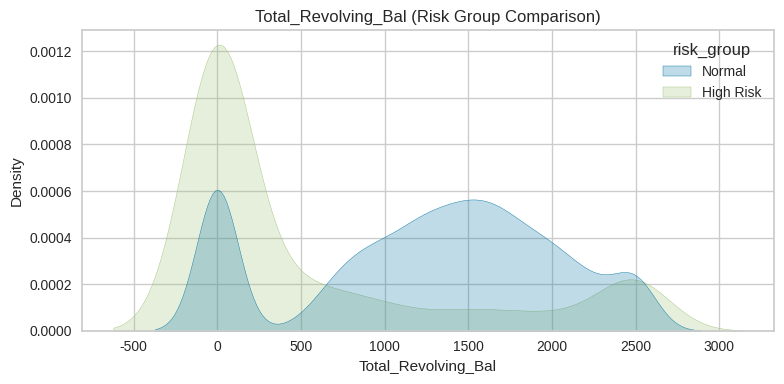

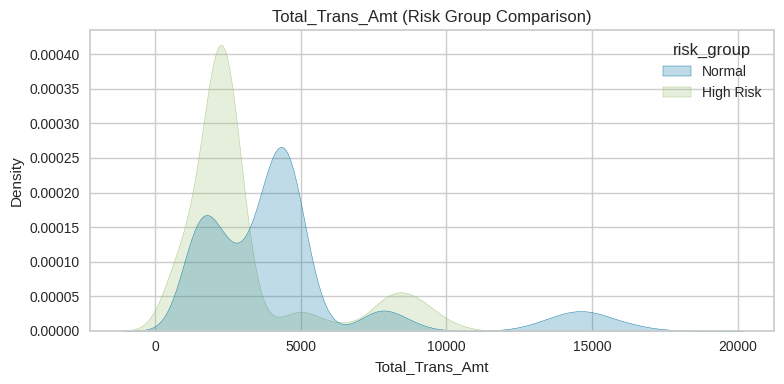

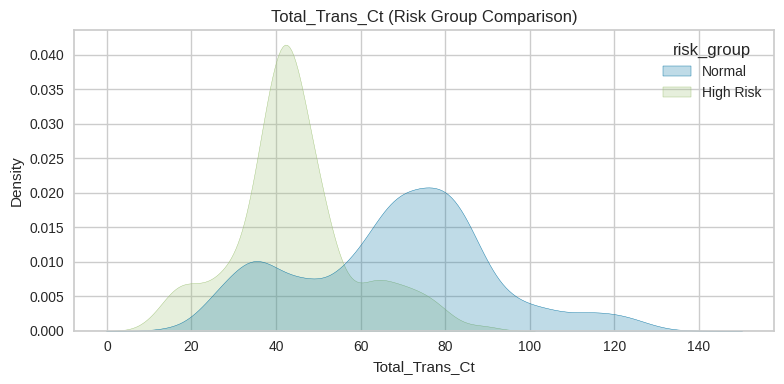

In [ ]:
for col in num_cols:
    plt.figure(figsize=(8, 4))

    sns.kdeplot(
        data=df,
        x=col,
        hue='risk_group',
        fill=True,
        common_norm=False
    )

    plt.title(f'{col} (Risk Group Comparison)')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()


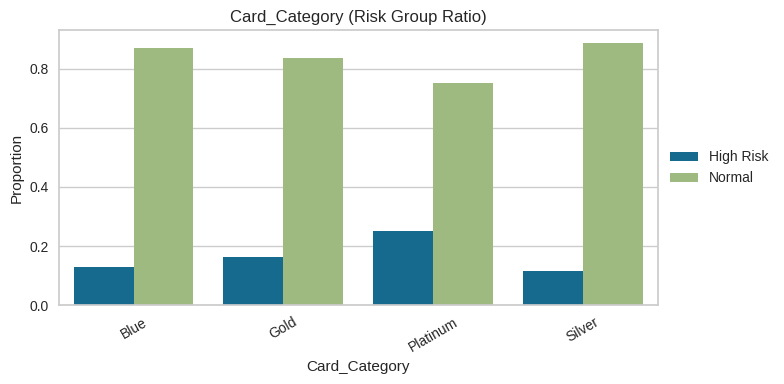

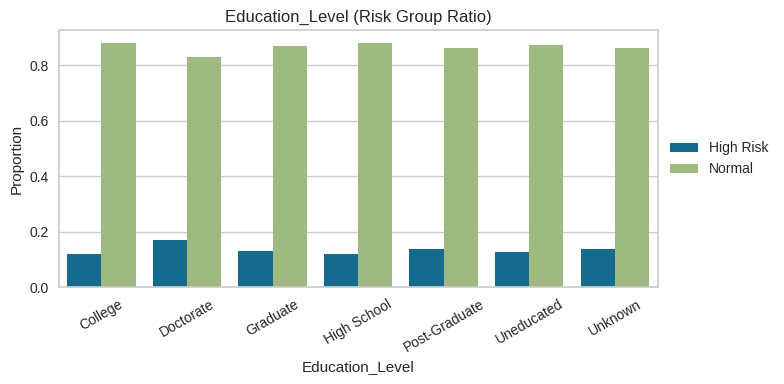

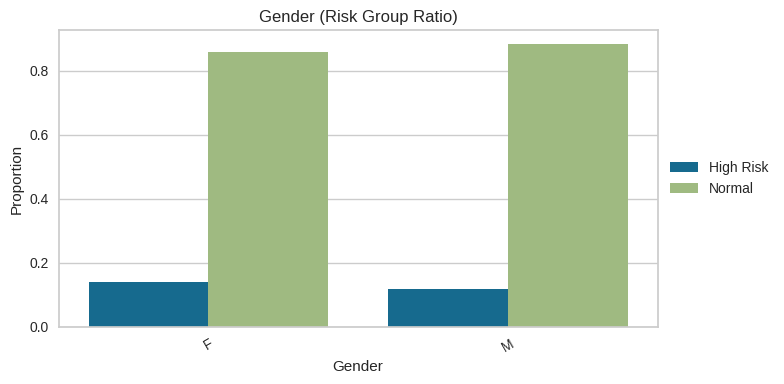

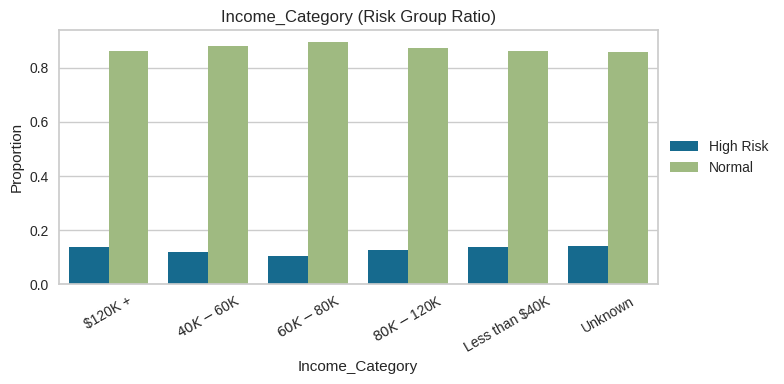

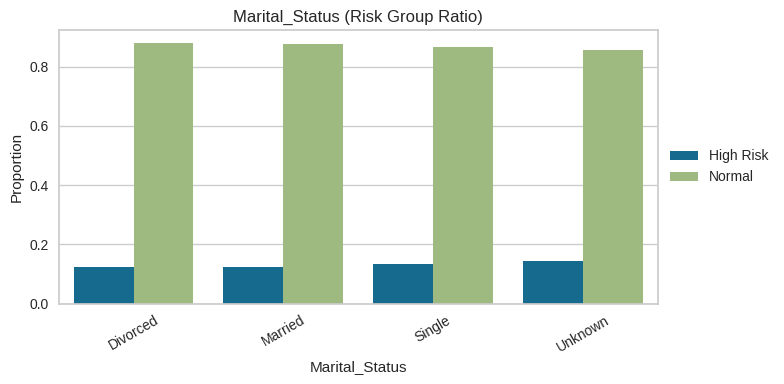

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(8, 4))

    prop_df = (
        df
        .groupby([col, 'risk_group'])
        .size()
        .reset_index(name='count')
    )

    # 비율 계산
    prop_df['ratio'] = prop_df.groupby(col)['count'].transform(lambda x: x / x.sum())

    sns.barplot(
        data=prop_df,
        x=col,
        y='ratio',
        hue='risk_group'
    )

    plt.title(f'{col} (Risk Group Ratio)')
    plt.ylabel('Proportion')
    plt.xlabel(col)
    plt.xticks(rotation=30)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()


카드 고객 이탈 분석 인사이트 요약
1. 핵심 결론 요약
High Risk 고객은 신용 한도나 연체 문제가 아니라, 카드를 생활 결제 수단에서 점진적으로 제거한 고객이다.
이탈은 갑작스러운 사건이 아니라 사용 빈도·사용률·관계 깊이가 서서히 붕괴되는 과정으로 나타난다.
2. 주요 인사이트 1 – 한도는 남아 있지만 사용하지 않는 고객
- Avg_Open_To_Buy는 High Risk 고객에서 더 높게 나타남
- Avg_Utilization_Ratio는 High Risk 고객이 0에 가까운 값에 집중
→ 카드 사용 의지가 이미 약화된 상태로, 한도 증액보다는 사용 트리거가 필요
3. 주요 인사이트 2 – 거래 횟수 감소가 가장 강력한 신호
- Total_Trans_Ct 분포에서 High Risk 고객이 명확히 낮은 구간에 집중
- 금액보다 빈도 감소가 이탈의 선행 지표
→ 월 거래 횟수 감소를 조기경보 지표로 활용 필요
4. 주요 인사이트 3 – 사용 추세 변화의 중요성
- Total_Ct_Chng_Q4_Q1, Total_Amt_Chng_Q4_Q1 모두 High Risk 고객에서 감소 구간 집중
→ 절대 사용량보다 변화율이 이탈 예측에 더 중요
5. 주요 인사이트 4 – 고객센터 접촉 증가
- Contacts_Count_12_mon이 High Risk 고객에서 더 큼
→ 반복 접촉은 충성도가 아니라 불만 누적 신호
6. 주요 인사이트 5 – 관계 깊이와 이탈
- Total_Relationship_Count가 적을수록 High Risk 비중 증가
→ 다상품 보유가 Lock-in 효과를 제공
7. 보조 인사이트 – 인구통계 변수
- 나이, 성별, 결혼 여부, 학력은 이탈의 직접 원인이 아님
- 행동 변화 변수와 결합될 때만 의미를 가짐
8. 실행 전략(Action Plan)
① 조기경보 룰 정의:
- 거래 횟수 QoQ -40% 이하 + Utilization < 0.15

② 우선 개입 대상:
- 사용 감소 + 고객센터 접촉 이력 고객

③ 캠페인 방향:
- 빈도 회복 중심 인센티브
- 단일상품 고객 대상 교차상품 제안

④ KPI:
- 거래 횟수 회복률
- 재사용 전환율
